# Model Development

In [69]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)  # Display all columns in the output

# Load the datasets
dis_fact = pd.read_csv('../eda/disasters_fact_table.csv')

dis_fact.head()


,disasterNumber,state,incidentType,declarationDate,incidentBeginDate,incidentEndDate,declarationType,declaration_year,declaration_month,declaration_quarter,incident_duration_days,declaration_lag_days,incident_open_flag,state_disaster_frequency,totalAmountIhpApproved,totalAmountHaApproved,totalAmountOnaApproved,totalObligatedAmountPa,totalObligatedAmountHmgp,target_pa_cost,target_total_recovery_cost,log_target_pa_cost,log_target_total_cost,pa_project_count,pa_total_obligated_sum,pa_total_obligated_mean,pa_total_obligated_median,pa_total_obligated_max,large,small,large_project_ratio,totalAmountIhpApproved_missing,totalAmountHaApproved_missing,totalAmountOnaApproved_missing,totalObligatedAmountPa_missing,totalObligatedAmountHmgp_missing
0,5529,OR,Fire,2024-08-09 00:00:00+00:00,2024-08-08 00:00:00+00:00,NaN,FM,2024,8,3,NaN,1,1,294,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.000000,0.000000,0.0,0.00,0.000000,0.000,0.00,0.0,0.0,0.000000,1,1,1,1,0
1,5528,OR,Fire,2024-08-06 00:00:00+00:00,2024-08-04 00:00:00+00:00,NaN,FM,2024,8,3,NaN,2,1,294,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.000000,0.000000,0.0,0.00,0.000000,0.000,0.00,0.0,0.0,0.000000,1,1,1,1,0
2,5527,OR,Fire,2024-08-02 00:00:00+00:00,2024-08-02 00:00:00+00:00,NaN,FM,2024,8,3,NaN,0,1,294,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.000000,0.000000,0.0,0.00,0.000000,0.000,0.00,0.0,0.0,0.000000,1,1,1,1,0
3,4312,CA,Severe Storm,2017-05-02 00:00:00+00:00,2017-02-08 00:00:00+00:00,2017-02-11 00:00:00+00:00,DR,2017,5,2,3.0,83,0,739,0.0,0.0,0.0,269934.77,1650.00,269934.77,271584.77,12.505939,12.512033,2.0,269934.77,134967.385000,134967.385,233307.18,1.0,1.0,0.500000,1,1,1,0,0
4,4251,AL,Severe Storm,2016-01-21 00:00:00+00:00,2015-12-23 00:00:00+00:00,2015-12-31 00:00:00+00:00,DR,2016,1,1,8.0,29,0,743,0.0,0.0,0.0,36201886.24,5530482.83,36201886.24,41732369.07,17.404622,17.546788,693.0,36201886.01,52239.373752,26674.610,1739135.15,51.0,642.0,0.073593,1,1,1,0,0


In [70]:
dis_fact.columns

Index(['disasterNumber', 'state', 'incidentType', 'declarationDate',
       'incidentBeginDate', 'incidentEndDate', 'declarationType',
       'declaration_year', 'declaration_month', 'declaration_quarter',
       'incident_duration_days', 'declaration_lag_days', 'incident_open_flag',
       'state_disaster_frequency', 'totalAmountIhpApproved',
       'totalAmountHaApproved', 'totalAmountOnaApproved',
       'totalObligatedAmountPa', 'totalObligatedAmountHmgp', 'target_pa_cost',
       'target_total_recovery_cost', 'log_target_pa_cost',
       'log_target_total_cost', 'pa_project_count', 'pa_total_obligated_sum',
       'pa_total_obligated_mean', 'pa_total_obligated_median',
       'pa_total_obligated_max', 'large', 'small', 'large_project_ratio',
       'totalAmountIhpApproved_missing', 'totalAmountHaApproved_missing',
       'totalAmountOnaApproved_missing', 'totalObligatedAmountPa_missing',
       'totalObligatedAmountHmgp_missing'],
      dtype='str')

### Baseline Model

In [ ]:
drop_cols = [
    # ids / raw dates - little predictive value and potential for leakage
    "disasterNumber",
    "declarationDate",
    "incidentBeginDate",
    "incidentEndDate",

    # targets
    "target_total_recovery_cost",
    "target_pa_cost",
    "log_target_pa_cost",
    "log_target_total_cost",

    # leakage: cost components
    "totalAmountIhpApproved",
    "totalAmountHaApproved",
    "totalAmountOnaApproved",
    "totalObligatedAmountPa",
    "totalObligatedAmountHmgp",

    # leakage: missing flags for target components
    "totalAmountIhpApproved_missing",
    "totalAmountHaApproved_missing",
    "totalAmountOnaApproved_missing",
    "totalObligatedAmountPa_missing",
    "totalObligatedAmountHmgp_missing",

    # leakage: post-event PA aggregates
    "pa_total_obligated_sum",
    "pa_total_obligated_mean",
    "pa_total_obligated_median",
    "pa_total_obligated_max",

    # project scope is prediction of recovery cost before declaration - all of these happen after declaration. 
    # Misleading signals for model to learn from.
    "pa_project_count",
    "large",
    "small",
    "large_project_ratio",

    # possible time leakage
    "incident_duration_days"
]

In [72]:
X = dis_fact.drop(columns=drop_cols)
y = dis_fact["log_target_total_cost"]

In [73]:
X.columns

Index(['state', 'incidentType', 'declarationType', 'declaration_year',
       'declaration_month', 'declaration_quarter', 'declaration_lag_days',
       'incident_open_flag', 'state_disaster_frequency'],
      dtype='str')

In [74]:
X = pd.get_dummies(X, columns=["state", "incidentType", "declarationType"], drop_first=True)

In [75]:
print(X.select_dtypes(include=["object", "datetime", "datetimetz"]).columns.tolist())

[]


In [76]:
X.isnull().sum().sort_values(ascending=False).head(20)

declaration_year            0
declaration_month           0
declaration_quarter         0
declaration_lag_days        0
incident_open_flag          0
state_disaster_frequency    0
state_AL                    0
state_AR                    0
state_AS                    0
state_AZ                    0
state_CA                    0
state_CO                    0
state_CT                    0
state_DC                    0
state_DE                    0
state_FL                    0
state_GA                    0
state_GU                    0
state_HI                    0
state_IA                    0
dtype: int64

In [77]:
dis_fact[dis_fact['log_target_total_cost'].isnull()].head()

,disasterNumber,state,incidentType,declarationDate,incidentBeginDate,incidentEndDate,declarationType,declaration_year,declaration_month,declaration_quarter,incident_duration_days,declaration_lag_days,incident_open_flag,state_disaster_frequency,totalAmountIhpApproved,totalAmountHaApproved,totalAmountOnaApproved,totalObligatedAmountPa,totalObligatedAmountHmgp,target_pa_cost,target_total_recovery_cost,log_target_pa_cost,log_target_total_cost,pa_project_count,pa_total_obligated_sum,pa_total_obligated_mean,pa_total_obligated_median,pa_total_obligated_max,large,small,large_project_ratio,totalAmountIhpApproved_missing,totalAmountHaApproved_missing,totalAmountOnaApproved_missing,totalObligatedAmountPa_missing,totalObligatedAmountHmgp_missing
21626,3428,CA,Biological,2020-03-13 00:00:00+00:00,2020-01-20 00:00:00+00:00,2023-05-11 00:00:00+00:00,EM,2020,3,1,1207.0,53,0,739,0.0,0.0,0.0,-23499530.3,0.0,-23499530.3,-23499530.3,NaN,NaN,75.0,9048942.72,120652.5696,55404.0,1612389.47,5.0,70.0,0.066667,1,1,1,0,1
21627,3428,CA,Biological,2020-03-13 00:00:00+00:00,2020-01-20 00:00:00+00:00,2023-05-11 00:00:00+00:00,EM,2020,3,1,1207.0,53,0,739,0.0,0.0,0.0,-23499530.3,0.0,-23499530.3,-23499530.3,NaN,NaN,75.0,9048942.72,120652.5696,55404.0,1612389.47,5.0,70.0,0.066667,1,1,1,0,1
21628,3428,CA,Biological,2020-03-13 00:00:00+00:00,2020-01-20 00:00:00+00:00,2023-05-11 00:00:00+00:00,EM,2020,3,1,1207.0,53,0,739,0.0,0.0,0.0,-23499530.3,0.0,-23499530.3,-23499530.3,NaN,NaN,75.0,9048942.72,120652.5696,55404.0,1612389.47,5.0,70.0,0.066667,1,1,1,0,1
21629,3428,CA,Biological,2020-03-13 00:00:00+00:00,2020-01-20 00:00:00+00:00,2023-05-11 00:00:00+00:00,EM,2020,3,1,1207.0,53,0,739,0.0,0.0,0.0,-23499530.3,0.0,-23499530.3,-23499530.3,NaN,NaN,75.0,9048942.72,120652.5696,55404.0,1612389.47,5.0,70.0,0.066667,1,1,1,0,1
21630,3428,CA,Biological,2020-03-13 00:00:00+00:00,2020-01-20 00:00:00+00:00,2023-05-11 00:00:00+00:00,EM,2020,3,1,1207.0,53,0,739,0.0,0.0,0.0,-23499530.3,0.0,-23499530.3,-23499530.3,NaN,NaN,75.0,9048942.72,120652.5696,55404.0,1612389.47,5.0,70.0,0.066667,1,1,1,0,1


In [78]:
X = X.fillna(0)
y = y.fillna(0)

In [79]:
X.isnull().sum().sort_values(ascending=False).head(20)

declaration_year            0
declaration_month           0
declaration_quarter         0
declaration_lag_days        0
incident_open_flag          0
state_disaster_frequency    0
state_AL                    0
state_AR                    0
state_AS                    0
state_AZ                    0
state_CA                    0
state_CO                    0
state_CT                    0
state_DC                    0
state_DE                    0
state_FL                    0
state_GA                    0
state_GU                    0
state_HI                    0
state_IA                    0
dtype: int64

In [80]:
y.isnull().sum()

np.int64(0)

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Linear Regression Baseline Model

In [82]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [83]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{name} Results:")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print("-" * 30)

evaluate(y_test, y_pred_lr, "Linear Regression")

Linear Regression Results:
RMSE: 3.3623
R²: 0.8405
------------------------------


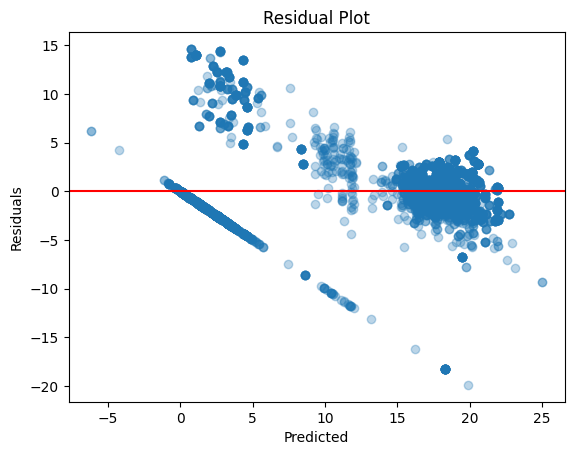

In [84]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_lr

plt.scatter(y_pred_lr, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

Clear diagonal line and distinct clusters. This means disaster cost doesn't fit linearly, more non-linear and segmented.

In [85]:
dis_fact.count()

disasterNumber                      32042
state                               32042
incidentType                        32042
declarationDate                     32042
incidentBeginDate                   32042
incidentEndDate                     31842
declarationType                     32042
declaration_year                    32042
declaration_month                   32042
declaration_quarter                 32042
incident_duration_days              31842
declaration_lag_days                32042
incident_open_flag                  32042
state_disaster_frequency            32042
totalAmountIhpApproved              32042
totalAmountHaApproved               32042
totalAmountOnaApproved              32042
totalObligatedAmountPa              32042
totalObligatedAmountHmgp            32042
target_pa_cost                      32042
target_total_recovery_cost          32042
log_target_pa_cost                  31984
log_target_total_cost               31984
pa_project_count                  

#### Random Forest Basline Model

In [86]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

evaluate(y_test, y_pred_rf, "Random Forest")

Random Forest Results:
RMSE: 1.5829
R²: 0.9646
------------------------------


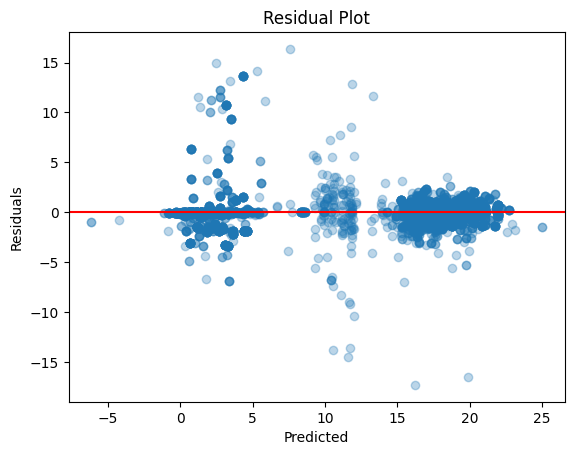

In [87]:
residuals = y_test - y_pred_rf

plt.scatter(y_pred_lr, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

Residuals are more scattered around the zero axis. Random forest baseline model captures the cost variance better.

In [88]:
feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

feat_imp.head(15)

,feature,importance
84,declarationType_EM,0.808382
0,declaration_year,0.042697
85,declarationType_FM,0.028612
3,declaration_lag_days,0.020231
1,declaration_month,0.018955
5,state_disaster_frequency,0.012708
72,incidentType_Severe Storm,0.007730
33,state_MS,0.007274
51,state_TN,0.006160
25,state_LA,0.006093


Almost 81% of importance is accorded declaration type. Meaning the rf model is likely heavily relying on Emergency declared disasters for prediction only (if EM => low cost, if not => high cost).

In [90]:
# Test RF without declarationType features to check for over reliance on these features
X_train_no_decl = X_train.drop(columns=[col for col in X_train.columns if "declarationType" in col])
X_test_no_decl  = X_test.drop(columns=[col for col in X_test.columns if "declarationType" in col])

rf.fit(X_train_no_decl, y_train)
y_pred_rf_no_decl = rf.predict(X_test_no_decl)

evaluate(y_test, y_pred_rf_no_decl, "RF without declarationType")

RF without declarationType Results:
RMSE: 2.0317
R²: 0.9418
------------------------------


R2 dropped slightly, not drastically. Proof that rf model isn't taking any shortcuts in making predictions.

c:\Users\brigh\Documents\amdari-internship\projects\terranova-predictive-analytics\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


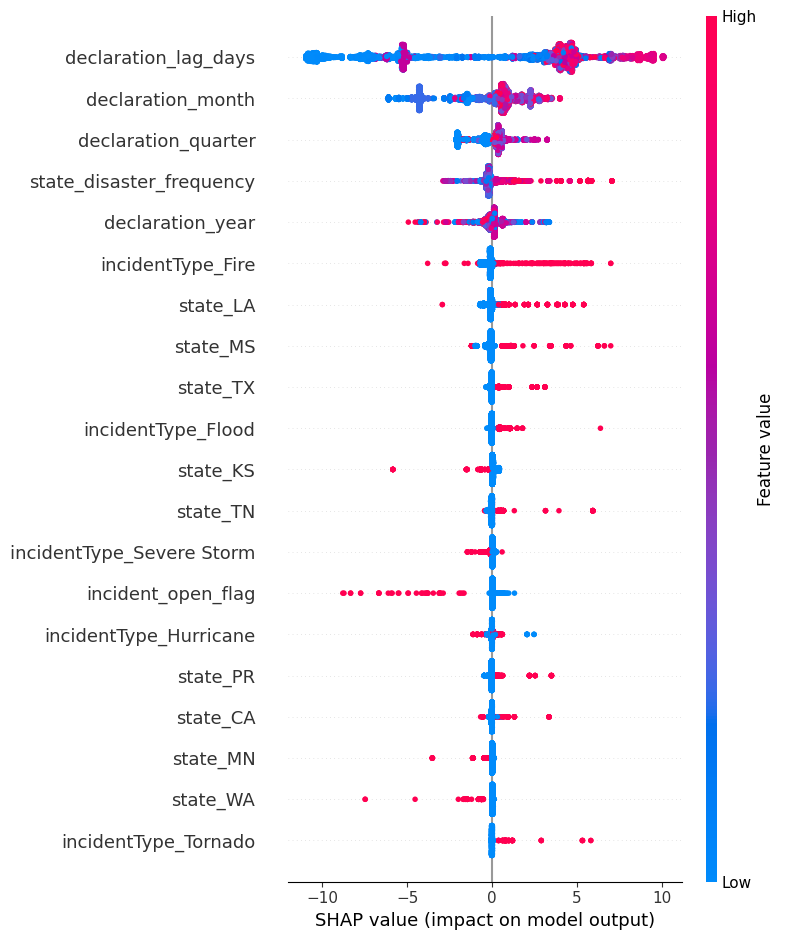

In [92]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

Further proof with advanced shap for model's feature explanability. lag_days is number 1 rather than declarationType, a good sign. So in essence, the longer the time between when a disaster happens and when it is declared, the higher the cost of total recovery from the disaster. Makes a lot of sense. 

State disaster frequency is also worthy of note. States more susceptible to disasters incur more cost. Declaration month as well being number 2 in importance tells us that some months in the year are peak fro disasters, which drives cost higher. This tallies with what was discovered in EDA, amazing. RF model really learnt well.

### Hyperparameter Tuning